# Segmentador de Zona de Trabajo
La idea es **segmentar** el cable del resto de la imagen,para dejar el fondo negro y el cable a color.

## Idea general
1. Pasarle un kernel gradiente horizontal para detectar sus bordes
2. Detectar bordes de cable
3. Transformada afín???



## Librerías
Se usará OpenCV y numpy. Matplotlib sólo para visualizar las imágenes.

# Paso 0 - Cargar imágenes y librerías


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [74]:

def showcv2image(img):
    #Función para mostrar OpenCV sin usar opencv
    if img is None or len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.axis('off')
    plt.show()


def showallcv2images(img_list):
    #Mostrar exactamente 6 imágenes OpenCV (BGR) en una grilla 3x2.
    #Asume img_list contiene 6 elementos y cada uno es un ndarray retornado por OpenCV.
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.ravel()  # Flatten para iterar fácilmente
    for ax, img in zip(axes, img_list):
        if img is None or len(img.shape) == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis('off')
    plt.tight_layout()
    plt.show()


In [3]:
path1 = "/home/grupo3/grupo3_ws/B1.jpg"
path2 = "/home/grupo3/grupo3_ws/B2.jpg"
path3 = "/home/grupo3/grupo3_ws/B3.jpg"
path4 = "/home/grupo3/grupo3_ws/B4.jpg"
path5 = "/home/grupo3/grupo3_ws/B5.jpg"
path6 = "/home/grupo3/grupo3_ws/B6.jpg"

In [75]:
# Se cargan las imágenes
img1 = cv2.imread(path1)
img2 = cv2.imread(path2)
img3 = cv2.imread(path3)
img4 = cv2.imread(path4)
img5 = cv2.imread(path5)
img6 = cv2.imread(path6)
img_array = [img1, img2, img3, img4, img5, img6]

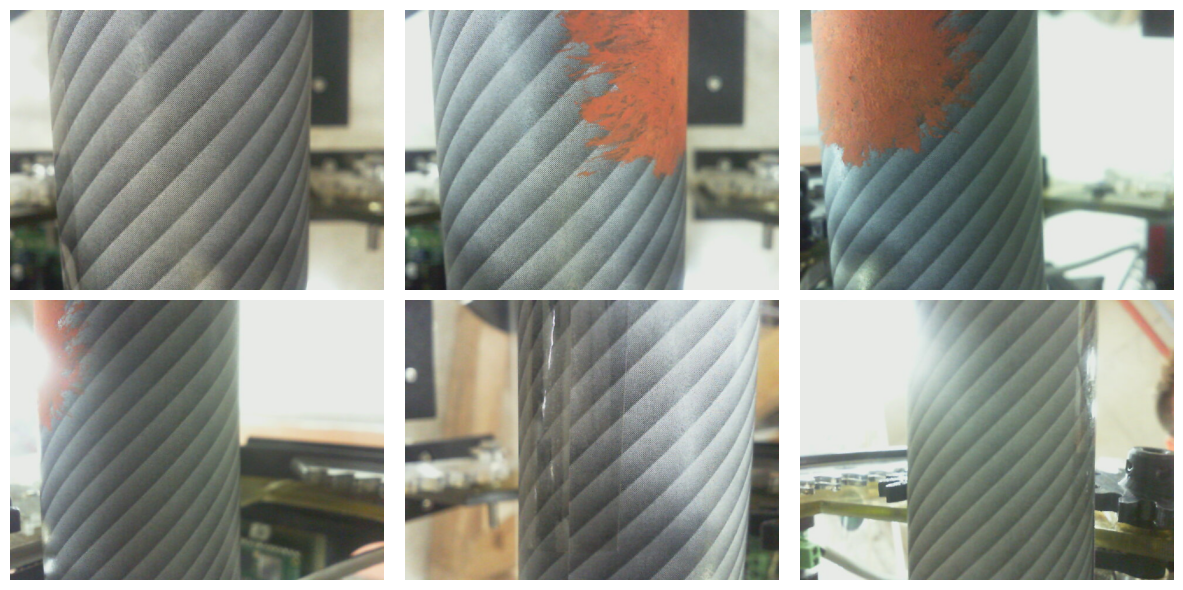

In [76]:
# Se muestran las imágenes para ver que cargaron bien
showallcv2images(img_array)

# Kernel gradiente horizontal
Ahora se le pasa un kernel de gradiente horizontal a la imagen (-1,0,1) para detectar los bordes del cable. 

In [59]:
image = img4

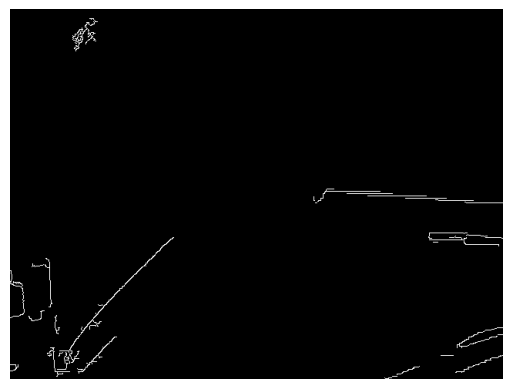

In [60]:
# Aplicar filtro Canny para comparar
edges_canny = cv2.Canny(image, 40, 205)
showcv2image(edges_canny)


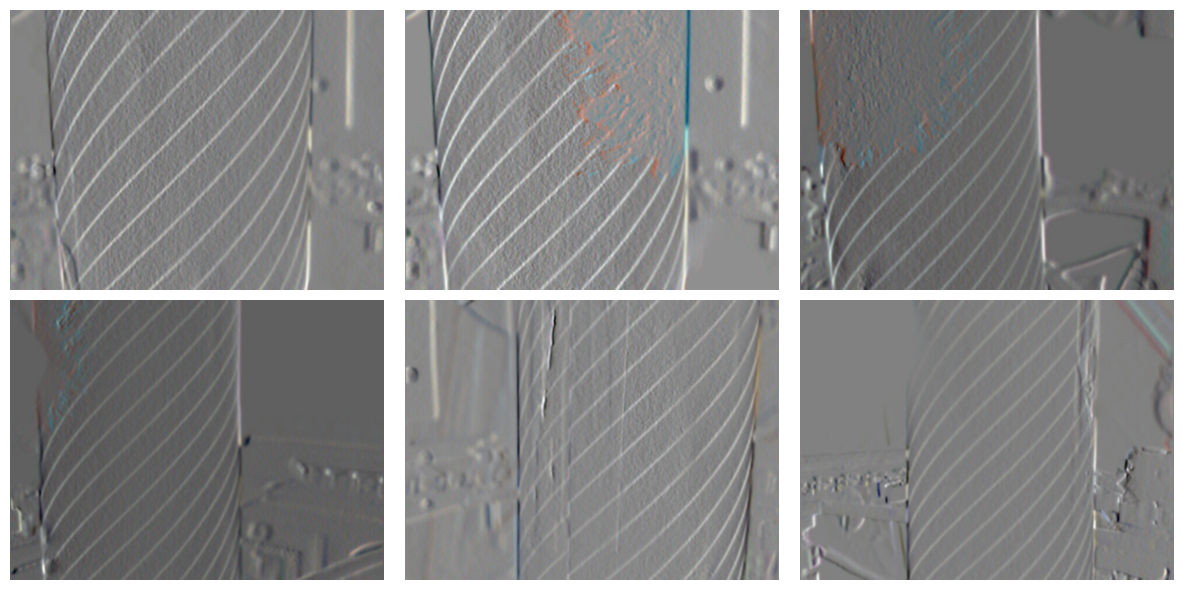

In [78]:
# Se prueba Sobel en x
sobelx_array= []
for img in img_array:
    # Aplicar filtro Sobel en x
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=11)
    sobelx_norm = cv2.normalize(sobelx, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    sobelx_array.append(sobelx_norm)

showallcv2images(sobelx_array)